# MLP on MNIST

In [1]:
import matplotlib.pyplot as plt
import mlflow
import pandas as pd
from IPython.display import display
from mlflow.tracking import MlflowClient

from train import load_mnist, run_experiment

%matplotlib inline

TRACKING_URI = "http://localhost:5000"
EXPERIMENT_NAME = "mnist-mlp"

mlflow.set_tracking_uri(TRACKING_URI)
client = MlflowClient()

print("tracking URI      :", mlflow.get_tracking_uri())
print("matplotlib backend:", plt.get_backend(), "(must NOT be 'agg')")

tracking URI      : http://localhost:5000
matplotlib backend: inline (must NOT be 'agg')


In [2]:
data = load_mnist(10000, 42)
X_train, X_val, y_train, y_val = data

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)

X_train: (10000, 784)
X_val  : (2000, 784)
y_train: (10000,)
y_val  : (2000,)


## Sweep grid


| Hyperparameter | Values swept |
| --- | --- |
| `learning_rate` | 0.001, 0.01, 0.1 |
| `batch_size` | 32, 256 |

Fixed Parameters:

| Held constant | Value |
| --- | --- |
| `hidden_size` | 128 |
| `epochs` | 30 |
| `n_train` | 10000 |
| `seed` | 42 |
| solver | `adam` |
| validation set | 2000 samples (same split for every run) |

In [3]:
%%time

LEARNING_RATES = [0.001, 0.01, 0.1]
BATCH_SIZES = [32, 256]

results = []

for lr in LEARNING_RATES:
    for bs in BATCH_SIZES:
        print(f"→ starting learning_rate={lr}, batch_size={bs} ...", flush=True)
        run_id, val_acc = run_experiment(
            learning_rate=lr,
            batch_size=bs,
            hidden_size=128,
            epochs=30,
            n_train=10000,
            seed=42,
            data=data,
        )
        results.append((lr, bs, run_id, val_acc))
        print(
            f"✓ done   learning_rate={lr}, batch_size={bs} → "
            f"final_val_accuracy={val_acc:.4f}  (run_id={run_id})\n",
            flush=True,
        )

print(f"Sweep complete: {len(results)} runs logged to {EXPERIMENT_NAME!r}")

→ starting learning_rate=0.001, batch_size=32 ...
epoch   1/30  train_loss=0.5410  train_acc=0.9289  val_acc=0.9080
epoch   2/30  train_loss=0.2571  train_acc=0.9483  val_acc=0.9305
epoch   3/30  train_loss=0.1897  train_acc=0.9626  val_acc=0.9405
epoch   4/30  train_loss=0.1448  train_acc=0.9730  val_acc=0.9430
epoch   5/30  train_loss=0.1121  train_acc=0.9824  val_acc=0.9450
epoch   6/30  train_loss=0.0873  train_acc=0.9856  val_acc=0.9445
epoch   7/30  train_loss=0.0678  train_acc=0.9894  val_acc=0.9475
epoch   8/30  train_loss=0.0523  train_acc=0.9924  val_acc=0.9470
epoch   9/30  train_loss=0.0397  train_acc=0.9937  val_acc=0.9485
epoch  10/30  train_loss=0.0302  train_acc=0.9946  val_acc=0.9490
epoch  11/30  train_loss=0.0233  train_acc=0.9950  val_acc=0.9490
epoch  12/30  train_loss=0.0188  train_acc=0.9943  val_acc=0.9455
epoch  13/30  train_loss=0.0149  train_acc=0.9956  val_acc=0.9485
epoch  14/30  train_loss=0.0140  train_acc=0.9967  val_acc=0.9445
epoch  15/30  train_loss=0

In [ ]:
runs_raw = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    order_by=["metrics.final_val_accuracy DESC"],
)

WANTED = [
    "run_id",
    "tags.mlflow.runName",
    "params.learning_rate",
    "params.batch_size",
    "metrics.final_train_loss",
    "metrics.final_val_accuracy",
    "metrics.best_val_accuracy",
    "metrics.overfit_gap",
]
columns = [c for c in WANTED if c in runs_raw.columns]
missing = [c for c in WANTED if c not in runs_raw.columns]
if missing:
    print("note — columns absent from the search result:", missing)

runs_table = runs_raw[columns].reset_index(drop=True)

display(runs_table)

runs_table.to_csv("results/runs_export.csv", index=False)
print(f"\nWrote results/runs_export.csv  ({len(runs_table)} rows)")

,run_id,tags.mlflow.runName,params.learning_rate,params.batch_size,metrics.final_train_loss,metrics.final_val_accuracy,metrics.best_val_accuracy,metrics.overfit_gap
0,7b60ba9571434f38a1c9f0629552bb07,mlp-lr0.001-bs32,0.001,32,0.005303,0.9525,0.9545,0.0463
1,d01821feb85b4e7f9839df94a60f25fd,mlp-lr0.001-bs256,0.001,256,0.023113,0.9470,0.9470,0.0492
2,26e10815ea6c4099824053de483639d5,mlp-lr0.01-bs256,0.01,256,0.028781,0.9465,0.9530,0.0440
3,d9648022a64241de85d54f45f5f77651,mlp-lr0.01-bs32,0.01,32,0.093162,0.9275,0.9420,0.0466
4,f18c9d6a9ee44d0e8189981fe2bc512a,mlp-lr0.1-bs256,0.1,256,0.538711,0.8160,0.8795,0.0244
5,4de2470e483541ea837cd2afdfb946b9,mlp-lr0.1-bs32,0.1,32,1.087633,0.6900,0.8010,0.0136



wrote results/runs_export.csv  (6 rows)


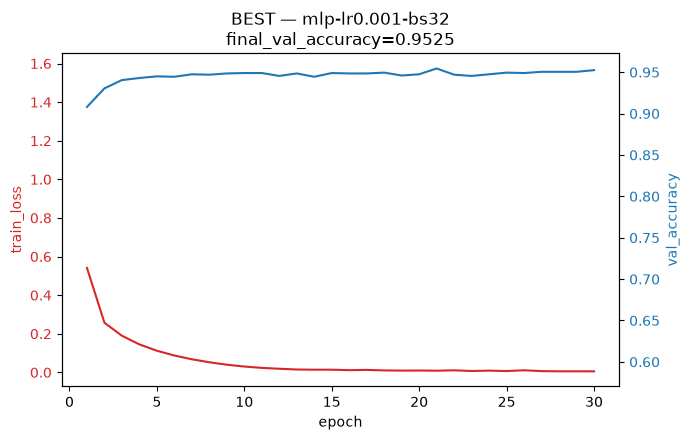

In [ ]:
def fetch_curve(run_id, metric):
    points = sorted(client.get_metric_history(run_id, metric), key=lambda m: m.step)
    return [m.step + 1 for m in points], [m.value for m in points]


def plot_run_curves(ax_loss, run_id, title, loss_ylim=None, acc_ylim=None):
    epochs, loss = fetch_curve(run_id, "train_loss")
    _, val_acc = fetch_curve(run_id, "val_accuracy")

    ax_loss.plot(epochs, loss, color="tab:red", label="train_loss")
    ax_loss.set_xlabel("epoch")
    ax_loss.set_ylabel("train_loss", color="tab:red")
    ax_loss.tick_params(axis="y", labelcolor="tab:red")

    ax_acc = ax_loss.twinx()
    ax_acc.plot(epochs, val_acc, color="tab:blue", label="val_accuracy")
    ax_acc.set_ylabel("val_accuracy", color="tab:blue")
    ax_acc.tick_params(axis="y", labelcolor="tab:blue")

    if loss_ylim:
        ax_loss.set_ylim(*loss_ylim)
    if acc_ylim:
        ax_acc.set_ylim(*acc_ylim)

    ax_loss.set_title(title)
    return ax_acc


def shared_limits(run_ids):
    losses, accs = [], []
    for run_id in run_ids:
        losses += fetch_curve(run_id, "train_loss")[1]
        accs += fetch_curve(run_id, "val_accuracy")[1]
    pad_l = 0.05 * (max(losses) - min(losses) or 1)
    pad_a = 0.05 * (max(accs) - min(accs) or 1)
    return (min(losses) - pad_l, max(losses) + pad_l), (min(accs) - pad_a, max(accs) + pad_a)


best = runs_table.iloc[0]
worst = runs_table.iloc[-1]
if best["run_id"] == worst["run_id"]:
    print("WARNING: only one run in the table — cells 8 and 9 will show the same run.")

LOSS_YLIM, ACC_YLIM = shared_limits([best["run_id"], worst["run_id"]])

fig, ax = plt.subplots(figsize=(7, 4.5))
plot_run_curves(
    ax,
    best["run_id"],
    f"BEST — {best.get('tags.mlflow.runName', best['run_id'])}\n"
    f"final_val_accuracy={float(best['metrics.final_val_accuracy']):.4f}",
    LOSS_YLIM,
    ACC_YLIM,
)
fig.tight_layout()
plt.show()

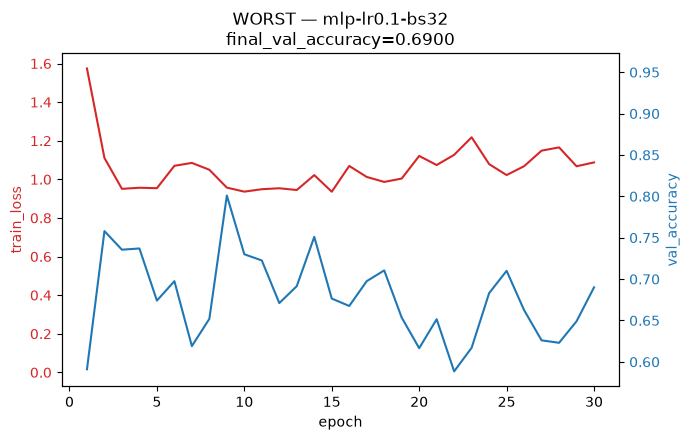

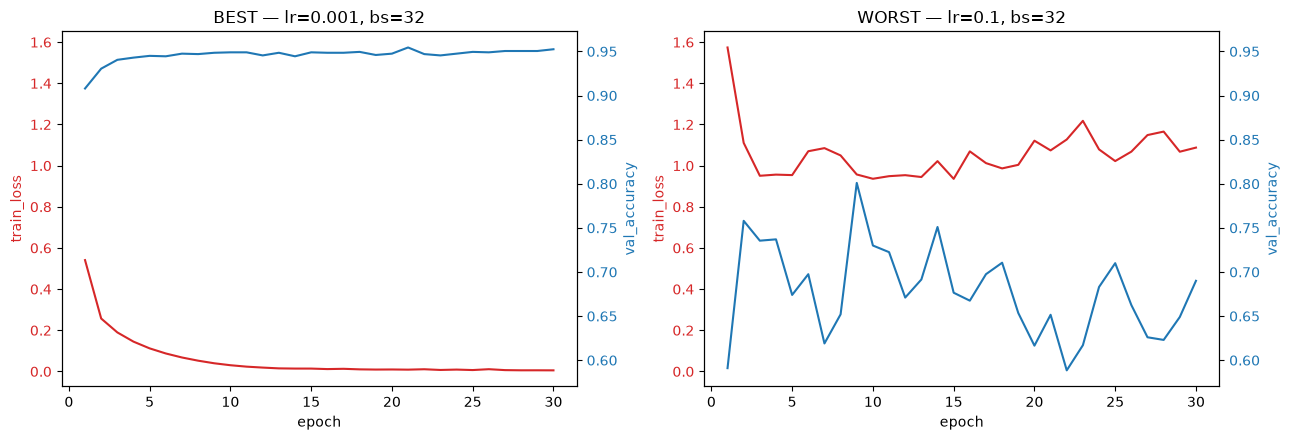

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
plot_run_curves(
    ax,
    worst["run_id"],
    f"WORST — {worst.get('tags.mlflow.runName', worst['run_id'])}\n"
    f"final_val_accuracy={float(worst['metrics.final_val_accuracy']):.4f}",
    LOSS_YLIM,
    ACC_YLIM,
)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, row, label in ((axes[0], best, "BEST"), (axes[1], worst, "WORST")):
    plot_run_curves(
        ax,
        row["run_id"],
        f"{label} — lr={row['params.learning_rate']}, bs={row['params.batch_size']}",
        LOSS_YLIM,
        ACC_YLIM,
    )
fig.tight_layout()
plt.show()

In [7]:
table = runs_table.assign(
    lr=runs_table["params.learning_rate"].astype(float),
    bs=runs_table["params.batch_size"].astype(int),
    acc=runs_table["metrics.final_val_accuracy"].astype(float),
)

lr_effect = table["acc"].max() - table["acc"].min()

pair_diffs = {}
for lr_value, group in table.groupby("lr"):
    if len(group) == 2:
        pair_diffs[lr_value] = abs(group["acc"].iloc[0] - group["acc"].iloc[1])
    else:
        print(f"note — learning_rate={lr_value} has {len(group)} run(s), not a pair; skipped")

bs_effect = sum(pair_diffs.values()) / len(pair_diffs) if pair_diffs else float("nan")

print("EFFECT SIZES (final_val_accuracy)")
print("─" * 52)
print(f"learning-rate effect  (max - min over all runs) : {lr_effect:.4f}")
print(f"batch-size effect     (mean |Δ| within lr pairs): {bs_effect:.4f}")
for lr_value, diff in sorted(pair_diffs.items()):
    print(f"    lr={lr_value:<6} |acc(bs=32) - acc(bs=256)| = {diff:.4f}")
print("─" * 52)
if lr_effect > bs_effect:
    print(f"→ LEARNING RATE has the larger effect ({lr_effect:.4f} vs {bs_effect:.4f}, "
          f"{lr_effect / bs_effect:.1f}x)" if bs_effect else "→ LEARNING RATE has the larger effect")
else:
    print(f"→ BATCH SIZE has the larger effect ({bs_effect:.4f} vs {lr_effect:.4f})")

print(f"\nBest run : lr={best['params.learning_rate']}, bs={best['params.batch_size']}, "
      f"final_val_accuracy={float(best['metrics.final_val_accuracy']):.4f}, "
      f"overfit_gap={float(best['metrics.overfit_gap']):.4f}")
print(f"Worst run: lr={worst['params.learning_rate']}, bs={worst['params.batch_size']}, "
      f"final_val_accuracy={float(worst['metrics.final_val_accuracy']):.4f}, "
      f"overfit_gap={float(worst['metrics.overfit_gap']):.4f}")

EFFECT SIZES (final_val_accuracy)
────────────────────────────────────────────────────
learning-rate effect  (max - min over all runs) : 0.2625
batch-size effect     (mean |Δ| within lr pairs): 0.0502
    lr=0.001  |acc(bs=32) - acc(bs=256)| = 0.0055
    lr=0.01   |acc(bs=32) - acc(bs=256)| = 0.0190
    lr=0.1    |acc(bs=32) - acc(bs=256)| = 0.1260
────────────────────────────────────────────────────
→ LEARNING RATE has the larger effect (0.2625 vs 0.0502, 5.2x)

Best run : lr=0.001, bs=32, final_val_accuracy=0.9525, overfit_gap=0.0463
Worst run: lr=0.1, bs=32, final_val_accuracy=0.6900, overfit_gap=0.0136


## Written Analysis (150–250 words)

_<write the analysis here — it must cover all three points below>_

1. **Best-performing run and why.** Name the winning `learning_rate` / `batch_size`
   combination from the table in cell 7 and explain why it won — e.g. the step size
   was large enough to converge within 30 epochs but small enough not to overshoot,
   and the batch size traded gradient noise against updates per epoch.

2. **Overfitting evidence from the `train_loss` vs `val_accuracy` trend.** Cite the
   curves in cells 8–9 and the `overfit_gap` column: point to where `train_loss`
   keeps falling while `val_accuracy` flattens or dips, and give the
   train/validation accuracy gap for the run that shows it most clearly.

3. **Which hyperparameter has the larger effect.** Quote the two numbers printed by
   cell 10 (learning-rate effect vs batch-size effect) and state which dominates,
   rather than describing the chart qualitatively.